# Voxelwise Random Field Theory Simulation Walkthrough

# **PART 1:** Setup and Data Simulation

We simulate fMRI datasets with controlled signal and noise properties.

For each subject $i = 1, \ldots, n$, we generate a 2D image $Y_i(x, y)$ of size $S \times S$ voxels (currently $S = 64$).

### 1. Noise Generation

Each voxel is drawn independently from a normal distribution:

$$
Y_i(x, y) \sim \mathrm{Normal}(0, 1)
$$

### 2. Signal Injection (optional)

For signal-present scenarios, we add a signal in a circular region:

$$
Y_i(x, y) = \text{SNR} \cdot \mathbb{1}_{\text{signal}}(x,y) + \epsilon_i(x,y)
$$

where $\mathbb{1}_{\text{signal}}$ is an indicator for the signal region.

### 3. Smoothing

To introduce spatial correlation, each image is convolved with a Gaussian smoothing kernel with parameter $\sigma$.

### 4. Final Dataset

The simulated dataset is:

$$
\{\, Y_i^{\text{smooth}}(x,y) \;:\; i=1,\dots,n \,\}
$$

## **1.1** Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

# Import voxelwise RFT functions
from rft_voxelwise import (
    simulate_null_data,
    voxelwise_rft_threshold,
    run_2d_sweep,
    estimate_fwer_rft,
    parse_spatial_shape,
    get_smoothed_truth_mask,
)

# Import plotting functions
from rft_plotters import (
    plot_3d_surface,
    plot_fwer_vs_sigma,
    plot_signal_heatmaps,
    plot_performance_landscape,
    plot_signal_and_data
)

# Import FWER testing functions
from test_fwer_CLEAN import (
    run_quick_test,
    run_standard_test,
    run_comprehensive_test,
    run_alpha_sweep_test
)
from IPython.display import Image as IPImage, display

# Set random seed for reproducibility
np.random.seed(42)

print("Imports done.")

Imports done.


## **1.2** Configuration Parameters

In [3]:
# Fixed parameters
n_subj = 20              # Number of subjects
img_size_length = 64     # Image size (64×64)
alpha = 0.05             # Significance level (FWER)
signal_radius = 6        # Radius of signal region (in voxels)
null_boundary = 1e-3     # Threshold for signal mask
n_thresh = 50            # Number of thresholds for LKC estimation

print(f"Configuration:")
print(f"  Sample size: {n_subj}")
print(f"  Image size: {img_size_length}×{img_size_length}")
print(f"  Alpha (FWER): {alpha}")
print(f"  Signal radius: {signal_radius} voxels")

Configuration:
  Sample size: 20
  Image size: 64×64
  Alpha (FWER): 0.05
  Signal radius: 6 voxels


# **PART 2:** Basic Demonstrations

See how RFT works through visual examples and single-case analyses.

## **2.1** Null Data Visualisation

We visualize what smoothed noise looks like with no signal.

Data shape: (20, 64, 64)
Data range: [-0.887, 0.793]


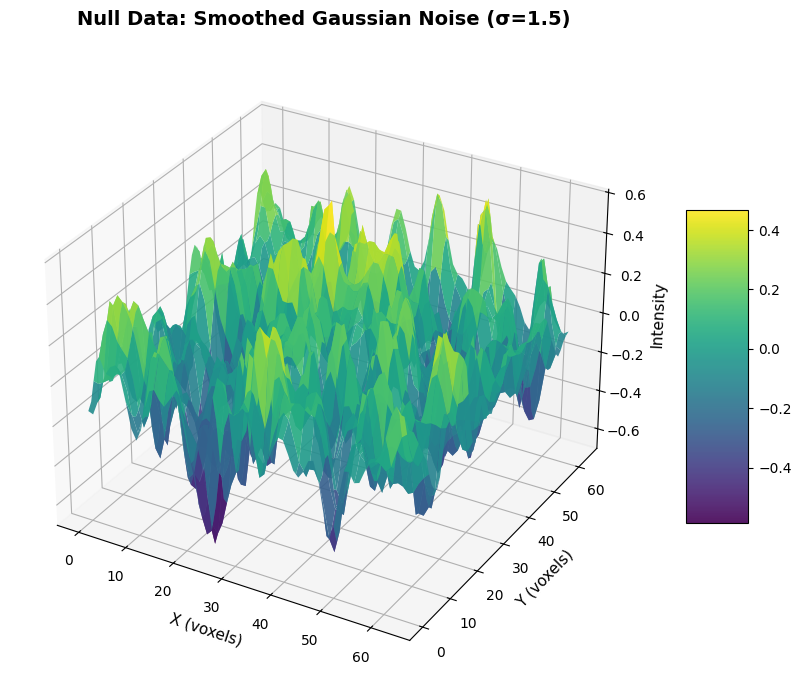

In [4]:
# Generate null data (no signal)
sigma_example = 1.5
data_null = simulate_null_data(
    n_subj=n_subj,
    img_size=img_size_length,
    sigma=sigma_example,
    ndim=2,
    snr=0,  # No signal
    signal_radius=0
)

print(f"Data shape: {data_null.shape}")
print(f"Data range: [{data_null.min():.3f}, {data_null.max():.3f}]")

# Plot first subject's data
plot_3d_surface(
    data_null[0],
    title=f"Null Data: Smoothed Gaussian Noise (σ={sigma_example})"
)
plt.show()

## **2.2** Signal-Present Data Visualization

Now we add a signal in the center of the image.

Data shape: (20, 64, 64)
Data range: [-0.769, 2.521]


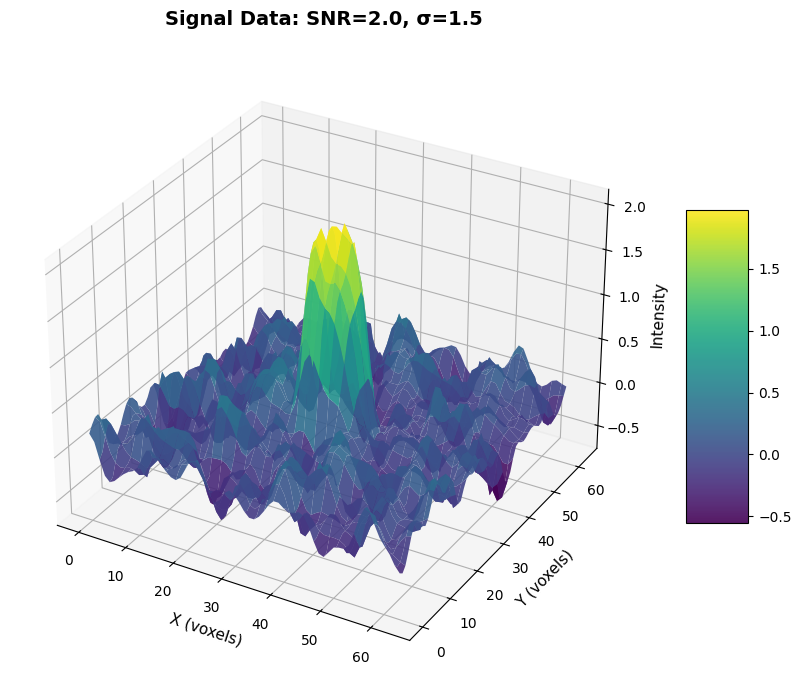

In [5]:
# Generate data with signal
snr_example = 2.0
data_signal = simulate_null_data(
    n_subj=n_subj,
    img_size=img_size_length,
    sigma=sigma_example,
    ndim=2,
    snr=snr_example,
    signal_radius=signal_radius
)

print(f"Data shape: {data_signal.shape}")
print(f"Data range: [{data_signal.min():.3f}, {data_signal.max():.3f}]")

# Plot first subject's data
plot_3d_surface(
    data_signal[0],
    title=f"Signal Data: SNR={snr_example}, σ={sigma_example}"
)
plt.show()

## **2.3** Signal Region Visualisation

The signal region is defined by smoothing, and we use a noise region to avoid edge effects in sensitivity calculations.

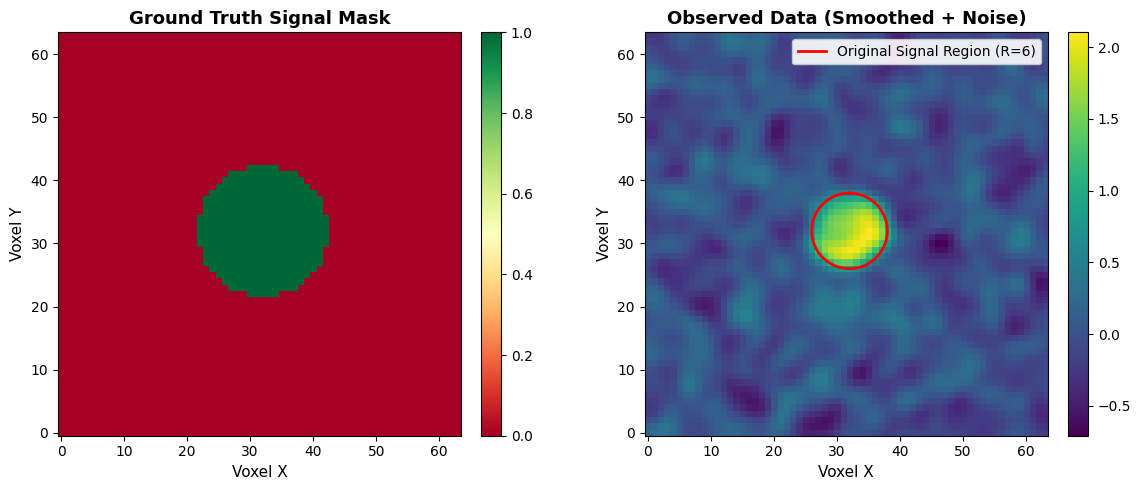

Signal region size: 341 voxels
Total image size: 4096 voxels
Signal coverage: 8.33%


In [22]:
# Get spatial shape
spatial_shape = parse_spatial_shape(img_size_length, ndim=2)

# Get smoothed truth mask
true_mask = get_smoothed_truth_mask(
    spatial_shape=spatial_shape,
    sigma=sigma_example,
    radius=signal_radius,
    null_boundary=null_boundary
)

# Plot signal and data
plot_signal_and_data(
    true_mask=true_mask,
    observed_field2d=data_signal[0],
    signal_radius=signal_radius,
)
plt.show()

print(f"Signal region size: {true_mask.sum()} voxels")
print(f"Total image size: {true_mask.size} voxels")
print(f"Signal coverage: {100*true_mask.sum()/true_mask.size:.2f}%")

## **2.4** RFT Threshold Computation

Compute the RFT threshold for one dataset to see how it works.

Computing RFT threshold...

Results:
  T-statistic range: [-5.533, 62.589]
  Max |t|: 62.589
  RFT threshold: 5.650
  Significant voxels: 183 (4.47%)


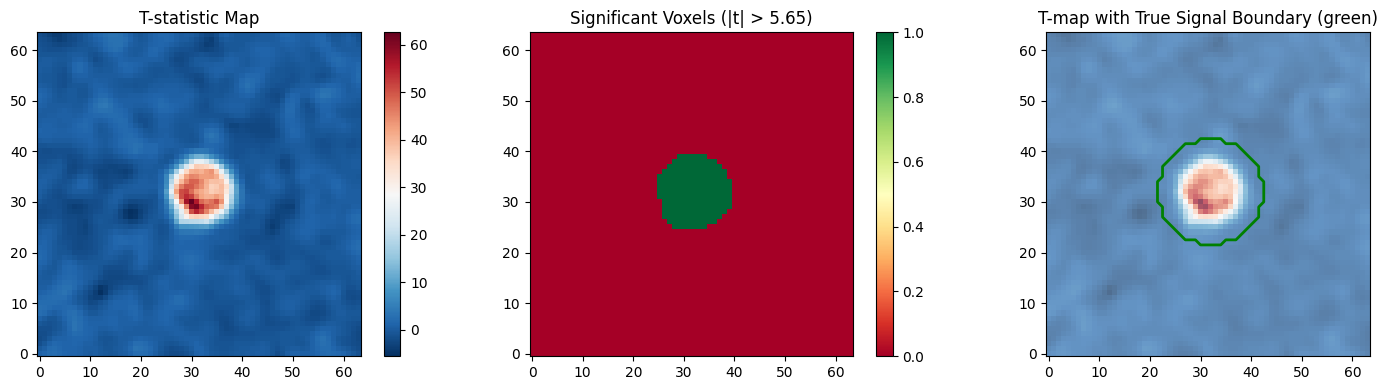

In [20]:
# Compute RFT threshold
print("Computing RFT threshold...")
tmap, threshold = voxelwise_rft_threshold(
    data_signal,
    labels=False,  # One-sample test
    alpha=alpha,
    n_thresh=n_thresh
)

print(f"\nResults:")
print(f"  T-statistic range: [{tmap.min():.3f}, {tmap.max():.3f}]")
print(f"  Max |t|: {np.abs(tmap).max():.3f}")
print(f"  RFT threshold: {threshold:.3f}")

# Check for significance
sig_map = np.abs(tmap) > threshold
n_sig = sig_map.sum()
print(f"  Significant voxels: {n_sig} ({100*n_sig/sig_map.size:.2f}%)")

# Visualize t-map
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# T-map
im1 = axes[0].imshow(tmap, cmap='RdBu_r', origin='lower')
axes[0].set_title('T-statistic Map')
plt.colorbar(im1, ax=axes[0])

# Significance map
im2 = axes[1].imshow(sig_map, cmap='RdYlGn', origin='lower')
axes[1].set_title(f'Significant Voxels (|t| > {threshold:.2f})')
plt.colorbar(im2, ax=axes[1])

# True signal overlay
axes[2].imshow(tmap, cmap='RdBu_r', origin='lower', alpha=0.7)
axes[2].contour(true_mask, levels=[0.5], colors='green', linewidths=2)
axes[2].set_title('T-map with True Signal Boundary (green)')

plt.tight_layout()
plt.show()

# **PART 3:** FWER Validation

We investigate whether voxelwise RFT properly controls false positives.

We validate that when there is **no signal** (null hypothesis), the method detects false positives at exactly nominal α = 0.05 rate.

## **3.1** FWER Control Test (Null Case)

Test if RFT properly controls FWER when there's no signal.

**Expected:** FWER should be close to α = 0.05.

In [8]:
# Test FWER with no signal
print("Testing FWER control...\n")

fwer_null = estimate_fwer_rft(
    n_runs=20,  # Quick test
    n_subj=n_subj,
    img_size=img_size_length,
    sigma=sigma_example,
    alpha=alpha,
    labels=False,
    ndim=2,
    n_thresh=n_thresh
)

print(f"\nResults:")
print(f"  Empirical FWER: {fwer_null:.3f}")
print(f"  Target α: {alpha:.3f}")
print(f"  Difference: {fwer_null - alpha:+.3f}")

if abs(fwer_null - alpha) <= 0.02:
    print(f"  GREAT: FWER within ±0.02 of target")
elif abs(fwer_null - alpha) <= 0.05:
    print(f"  GOOD: FWER within ±0.05 of target")
else:
    print(f"  CHECK: FWER deviates from target")

Testing FWER control...


Results:
  Empirical FWER: 0.150
  Target α: 0.050
  Difference: +0.100
  CHECK: FWER deviates from target


## **3.2** FWER vs Smoothing Parameter

Test how FWER varies with smoothing parameter σ.

**Expected:** FWER should remain close to α across different smoothing levels.

Testing FWER across 4 smoothing levels...
Starting Sweep (RFT): 4 sigmas x 1 SNRs
  > Processing Sigma = 0.0...
  > Processing Sigma = 1.0...
  > Processing Sigma = 2.0...
  > Processing Sigma = 3.0...
Sweep Complete.


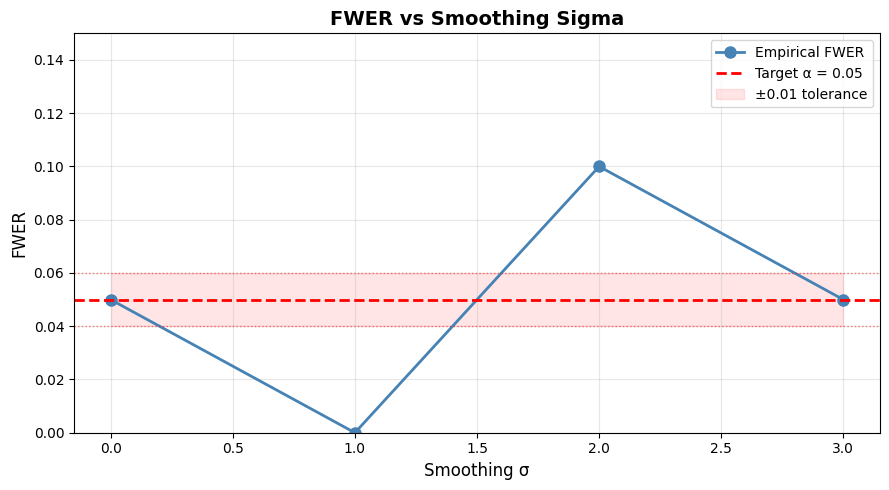


FWER Results:
  σ=0.0: FWER=0.050 GOOD
  σ=1.0: FWER=0.000 GOOD
  σ=2.0: FWER=0.100 GOOD
  σ=3.0: FWER=0.050 GOOD


In [30]:
# Define sigma range (coarse for speed)
test_sigmas_null = [0.0, 1.0, 2.0, 3.0]
snr_null = [0.0]  # Null case

print(f"Testing FWER across {len(test_sigmas_null)} smoothing levels...")

# Run sweep
sens_mat_null, fwer_mat_null = run_2d_sweep(
    n_runs=20,
    n_subj=n_subj,
    img_size=img_size_length,
    snr_levels=snr_null,
    sigma_levels=test_sigmas_null,
    alpha=alpha,
    signal_radius=signal_radius,
    labels=False,
    ndim=2,
    n_thresh=n_thresh,
    null_boundary=null_boundary,
    verbose=True
)

# Extract FWER values
fwer_vs_sigma = fwer_mat_null[:, 0]

# Plot
plot_fwer_vs_sigma(
    sigma_levels=test_sigmas_null,
    fwer_vals=fwer_vs_sigma,
    alpha=alpha
)
plt.show()

# Print results
print(f"\nFWER Results:")
for sigma, fwer in zip(test_sigmas_null, fwer_vs_sigma):
    status = "GOOD" if abs(fwer - alpha) <= 0.05 else "BAD"
    print(f"  σ={sigma:.1f}: FWER={fwer:.3f} {status}")

## **3.3** Standard Validation (100 runs) with Diagnostic Plots

Testing: n=20, sigma=1.5, alpha=0.05, 100 runs...
FWER: 0.0300 (target: 0.0500)

Saved: fwer_barplot.png
Saved: fwer_qqplot.png
STANDARD TEST RESULTS
  Empirical FWER: 0.030 (Target: 0.05)
  Mean threshold: 5.644 ± 0.009
  Threshold range: [5.618, 5.664]

Assessment: GOOD


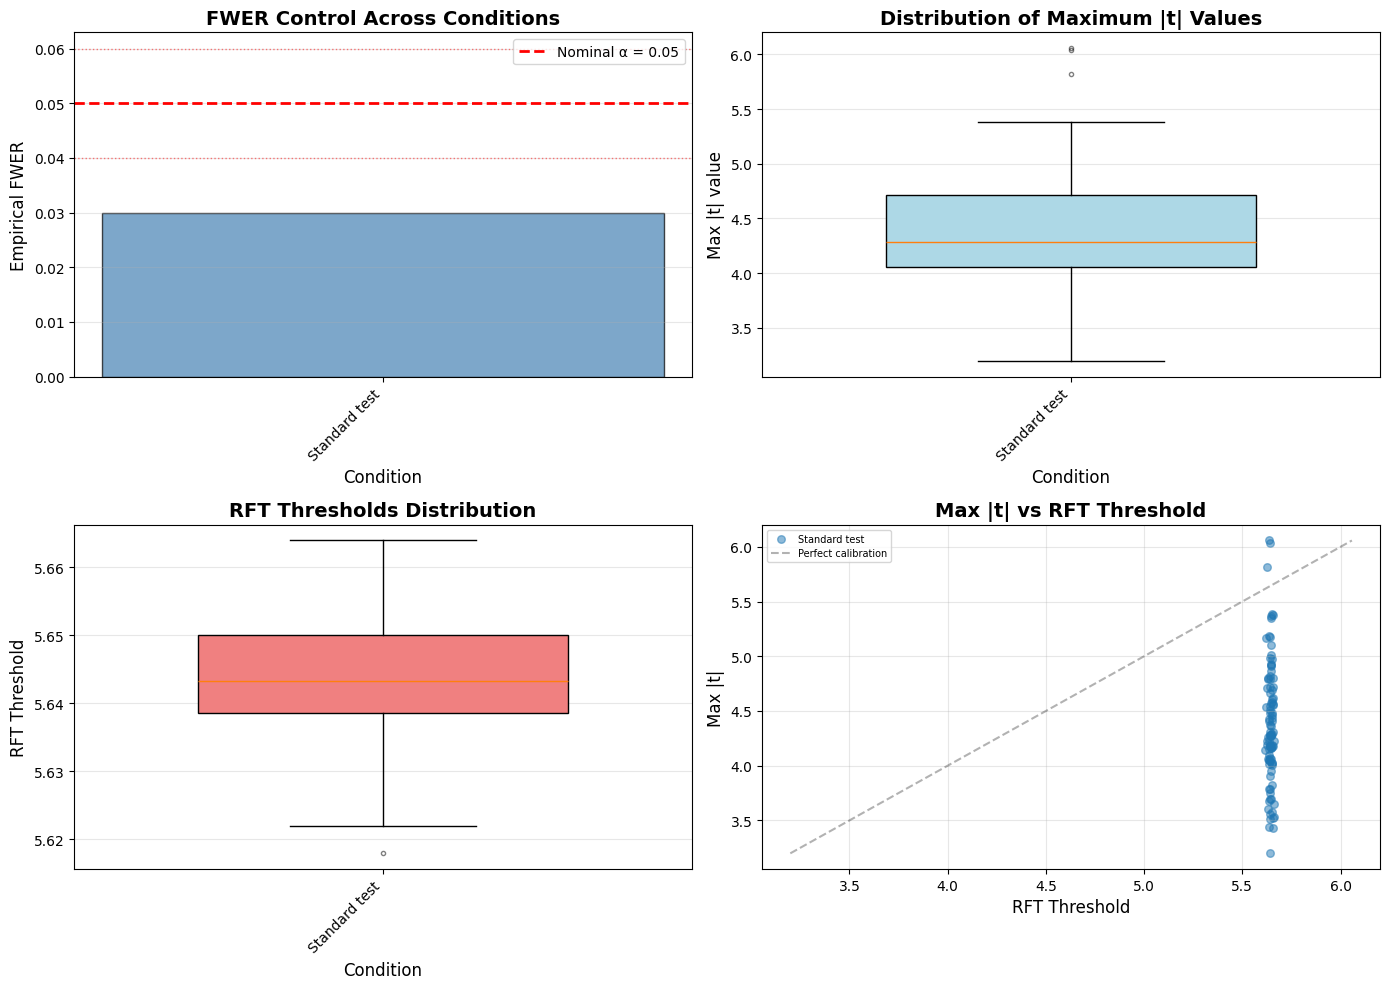

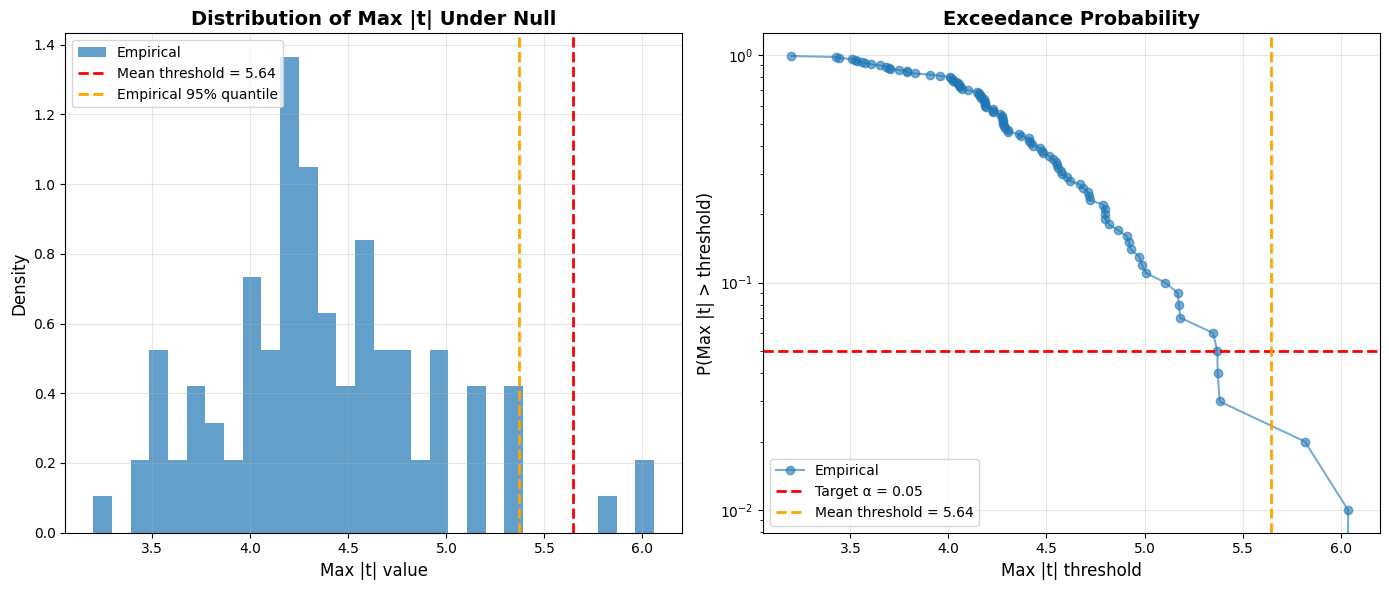

In [10]:
# Run standard test
fwer_std, max_t_std, thrs_std = run_standard_test()

print("STANDARD TEST RESULTS")
print(f"  Empirical FWER: {fwer_std:.3f} (Target: 0.05)")
print(f"  Mean threshold: {thrs_std.mean():.3f} ± {thrs_std.std():.3f}")
print(f"  Threshold range: [{thrs_std.min():.3f}, {thrs_std.max():.3f}]")

if abs(fwer_std - 0.05) <= 0.02:
    print("\nAssessment: GREAT")
elif abs(fwer_std - 0.05) <= 0.05:
    print("\nAssessment: GOOD")
else:
    print("\nAssessment: CHECK")

#### Interpretation Guide

**First Image:**
- Top-left: FWER bar (should be ~0.05)
- Top-right: Max |t| distribution
- Bottom-left: **Threshold stability** (tight = good!)
- Bottom-right: Calibration scatter

**Second Image:**
- Histogram: Distribution of max |t| under null
- Exceedance curve: Should cross α=0.05 at threshold

**Success Criteria:**
- ✓ FWER = 0.03-0.07
- ✓ Threshold SD < 0.05
- ✓ Exceedance crosses α at threshold

## **3.4** Comprehensive Validation (across multiple conditions)

Condition: Small image, low smoothing
Testing: n=20, sigma=1.0, alpha=0.05, 100 runs...
FWER: 0.0300 (target: 0.0500)

Condition: Medium image, medium smoothing
Testing: n=20, sigma=1.5, alpha=0.05, 100 runs...
FWER: 0.0800 (target: 0.0500)

Condition: Large image, high smoothing
Testing: n=20, sigma=2.0, alpha=0.05, 100 runs...
FWER: 0.0800 (target: 0.0500)

Condition: Medium image, small sample
Testing: n=10, sigma=1.5, alpha=0.05, 100 runs...
FWER: 0.0500 (target: 0.0500)

Condition: Medium image, large sample
Testing: n=40, sigma=1.5, alpha=0.05, 100 runs...
FWER: 0.0100 (target: 0.0500)


FWER SUMMARY (α = 0.05)
Condition                               FWER               95% CI  Threshold     Status
------------------------------------------------------------------------------------------
Small image, low smoothing            0.0300 [0.0103, 0.0845]      5.302       PASS
Medium image, medium smoothing        0.0800 [0.0411, 0.1500]      5.644       PASS
Large image, high smoothing 

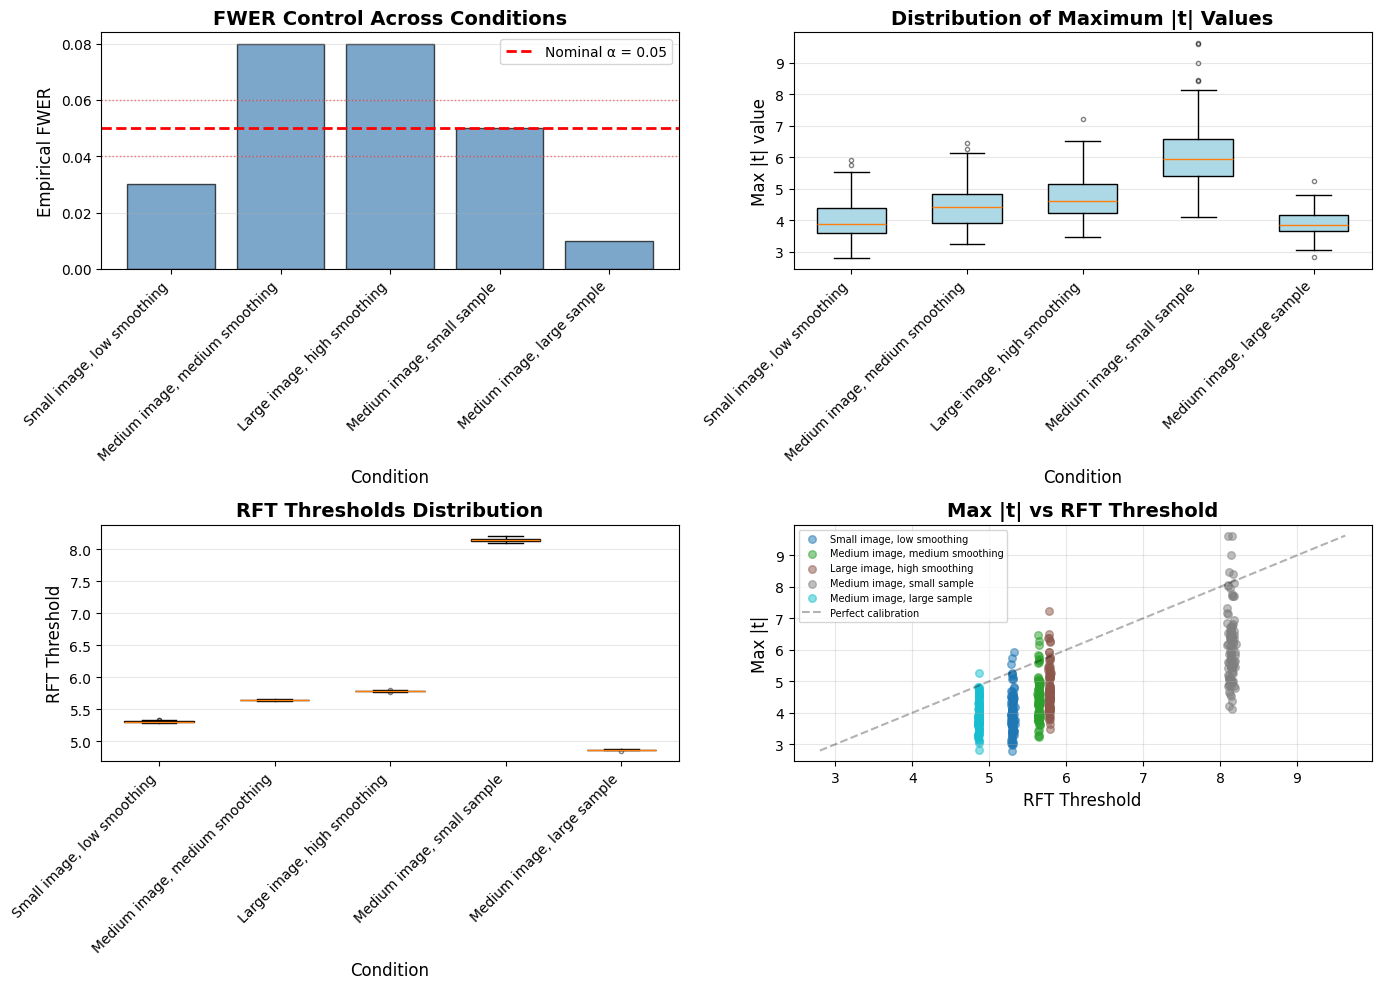

In [11]:
run_comp = input("Run comprehensive test? (y/n): ").strip().lower()

if run_comp == 'y':
    results_comprehensive = run_comprehensive_test()
    
    print("\n" + "="*80)
    print("RESULTS:")
    for cond, data in results_comprehensive.items():
        fwer = data['empirical_fwer']
        status = "good" if 0.02 <= fwer <= 0.08 else "bad"
        print(f"{cond}: FWER={fwer:.3f} {status}")
else:
    print("Skipped.")
    results_comprehensive = None

## **3.5** Alpha Sweep

Verify control at α = 0.01, 0.05, 0.10.

Testing: n=20, sigma=1.5, alpha=0.01, 100 runs...
FWER: 0.0100 (target: 0.0100)

Testing: n=20, sigma=1.5, alpha=0.05, 100 runs...
FWER: 0.0700 (target: 0.0500)

Testing: n=20, sigma=1.5, alpha=0.1, 100 runs...
FWER: 0.1400 (target: 0.1000)


Alpha Sweep Results:
   Nominal α             FWER  Threshold         Diff
----------------------------------------------------
       0.010           0.0100     6.4813       0.0000
       0.050           0.0700     5.6453       0.0200
       0.100           0.1400     5.2916       0.0400

Alpha sweep complete!
Plot displayed below.


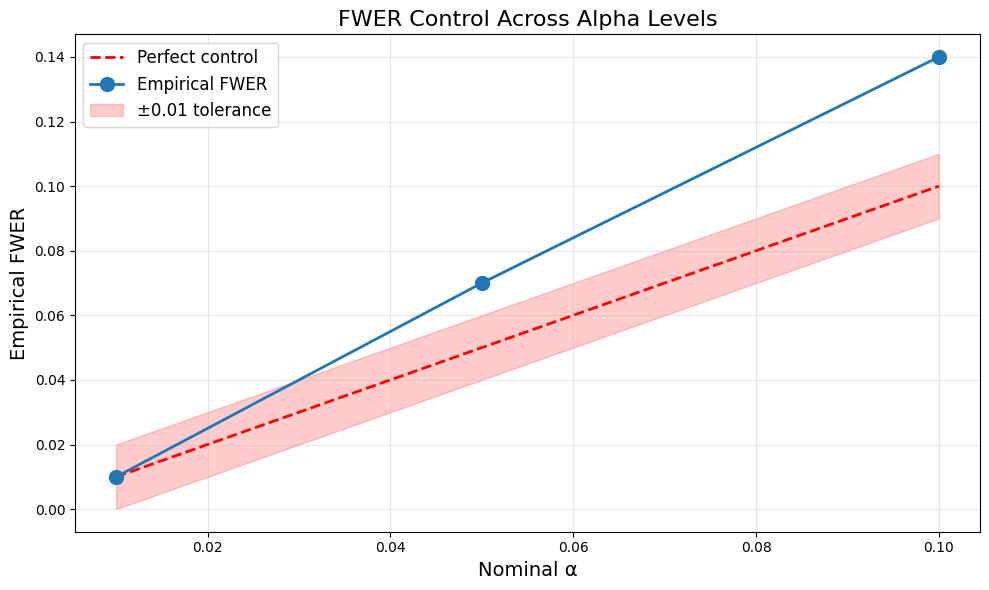

In [12]:
run_alpha = input("Run alpha sweep? (y/n): ").strip().lower()

if run_alpha == 'y':
    results_alpha = run_alpha_sweep_test()
    
    # The function already displays the plot, so we don't need to do it again
    print("\nAlpha sweep complete!")
    print("Plot displayed below.")
else:
    print("Skipped.")
    results_alpha = None

# **PART 4:** Performance Analysis

## **4.1** Signal Detection Performance

Test sensitivity (power) and false positive rate across different SNR and smoothing levels.

In [13]:
# Define parameter grids (coarse for speed)
test_snrs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
test_sigmas = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

print(f"Testing {len(test_sigmas)} smoothing levels × {len(test_snrs)} SNR levels")
print(f"Total conditions: {len(test_sigmas) * len(test_snrs)}")
print(f"Estimated time: ~30 seconds\n")

user_input = input("Continue? (y/n): ").strip().lower()

if user_input == 'y':
    # Run sweep
    sens_mat, fwer_mat = run_2d_sweep(
        n_runs=20,
        n_subj=n_subj,
        img_size=img_size_length,
        snr_levels=test_snrs,
        sigma_levels=test_sigmas,
        alpha=alpha,
        signal_radius=signal_radius,
        labels=False,
        ndim=2,
        n_thresh=n_thresh,
        null_boundary=null_boundary,
        verbose=True
    )
    
else:
    print("Skipped.")
    # Use dummy data for plotting demonstration
    sens_mat = np.random.rand(len(test_sigmas), len(test_snrs))
    fwer_mat = np.random.rand(len(test_sigmas), len(test_snrs)) * 0.1

Testing 7 smoothing levels × 7 SNR levels
Total conditions: 49
Estimated time: ~30 seconds

Starting Sweep (RFT): 7 sigmas x 7 SNRs
  > Processing Sigma = 0.0...
  > Processing Sigma = 0.5...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.5...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.5...
  > Processing Sigma = 3.0...
Sweep Complete.


## **4.2** Heatmap Visualisations

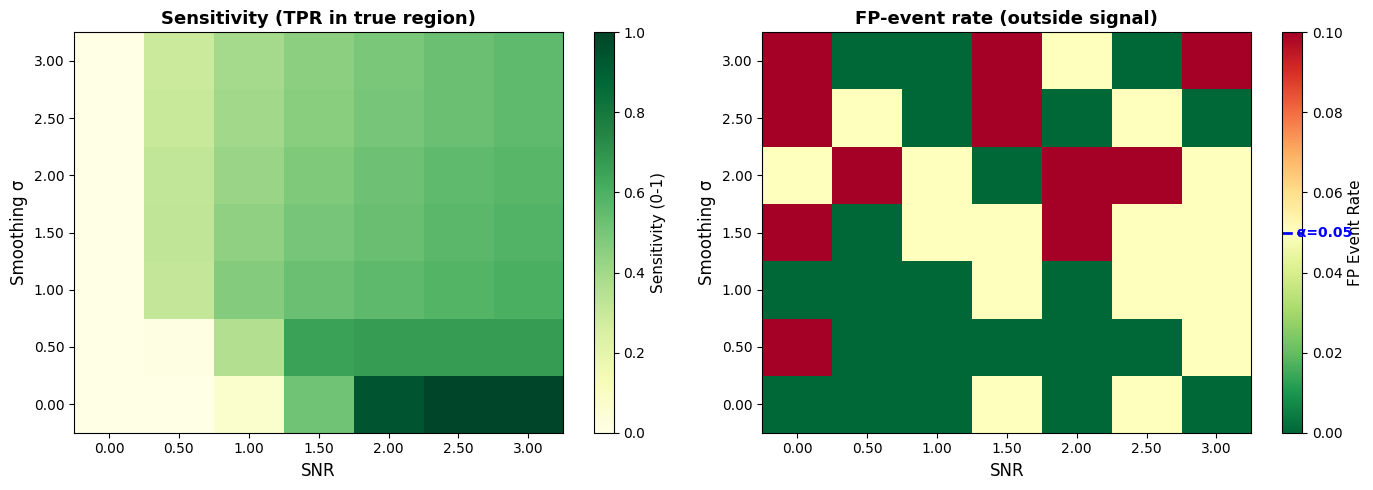

In [14]:
# Plot heatmaps
plot_signal_heatmaps(
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    sens_matrix=sens_mat,
    fp_event_matrix=fwer_mat,
    alpha=alpha
)
plt.show()

## **4.3** 3D Performance Landscape

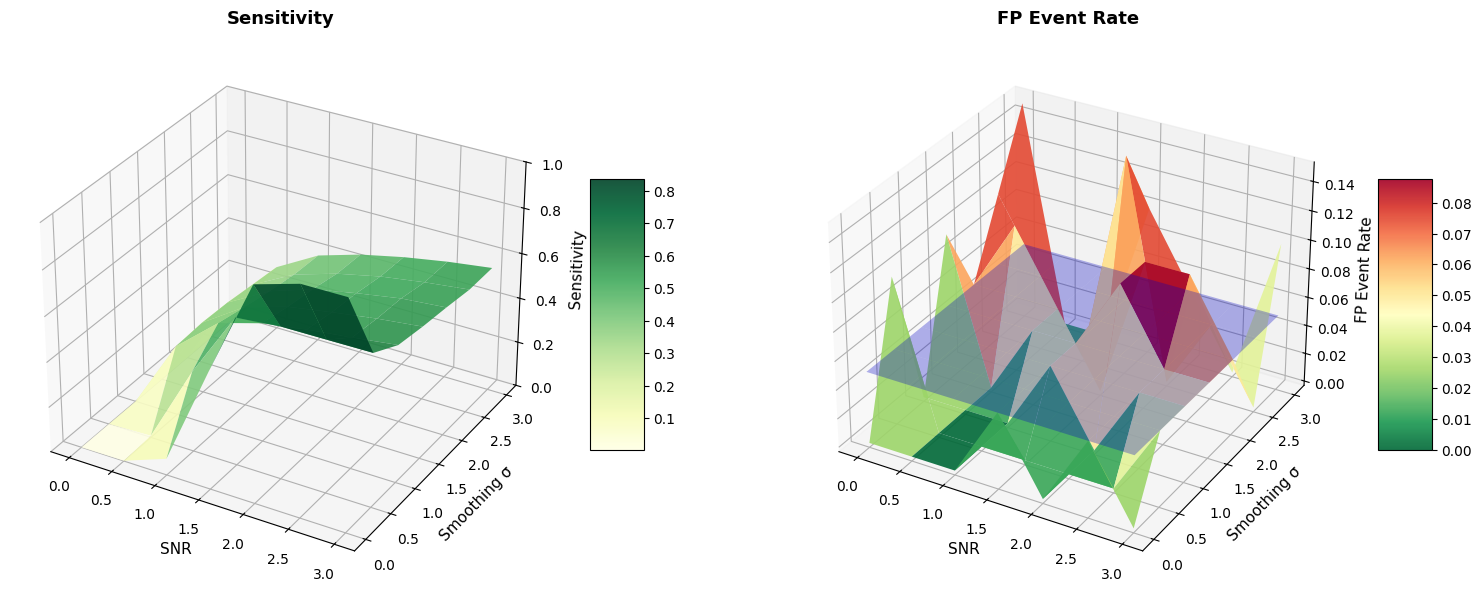

In [15]:
# Plot 3D landscape
plot_performance_landscape(
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    sens_matrix=sens_mat,
    fp_event_matrix=fwer_mat,
    alpha=alpha
)
plt.show()

## **4.4** Effect of Sample Size

Test how performance varies with number of subjects.

In [16]:
# Define sample sizes to test
n_values = [10, 20, 30]

print(f"Testing {len(n_values)} sample sizes: {n_values}")

user_input = input("Continue? (y/n): ").strip().lower()

if user_input == 'y':
    varied_n_metrics = []
    
    for n_subj_temp in n_values:
        print(f"\nProcessing n={n_subj_temp}...")
        
        sens_mat_n, fwer_mat_n = run_2d_sweep(
            n_runs=20,
            n_subj=n_subj_temp,
            img_size=img_size_length,
            snr_levels=test_snrs,
            sigma_levels=test_sigmas,
            alpha=alpha,
            signal_radius=signal_radius,
            labels=False,
            ndim=2,
            n_thresh=n_thresh,
            null_boundary=null_boundary,
            verbose=True
        )
        
        varied_n_metrics.append((sens_mat_n, fwer_mat_n))
    
    print("\nAll sample sizes complete!")
else:
    print("Skipped.")

Testing 3 sample sizes: [10, 20, 30]

Processing n=10...
Starting Sweep (RFT): 7 sigmas x 7 SNRs
  > Processing Sigma = 0.0...
  > Processing Sigma = 0.5...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.5...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.5...
  > Processing Sigma = 3.0...
Sweep Complete.

Processing n=20...
Starting Sweep (RFT): 7 sigmas x 7 SNRs
  > Processing Sigma = 0.0...
  > Processing Sigma = 0.5...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.5...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.5...
  > Processing Sigma = 3.0...
Sweep Complete.

Processing n=30...
Starting Sweep (RFT): 7 sigmas x 7 SNRs
  > Processing Sigma = 0.0...
  > Processing Sigma = 0.5...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.5...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.5...
  > Processing Sigma = 3.0...
Sweep Complete.

All sample sizes complete!


## **4.5** Visualise Effect of Sample Size

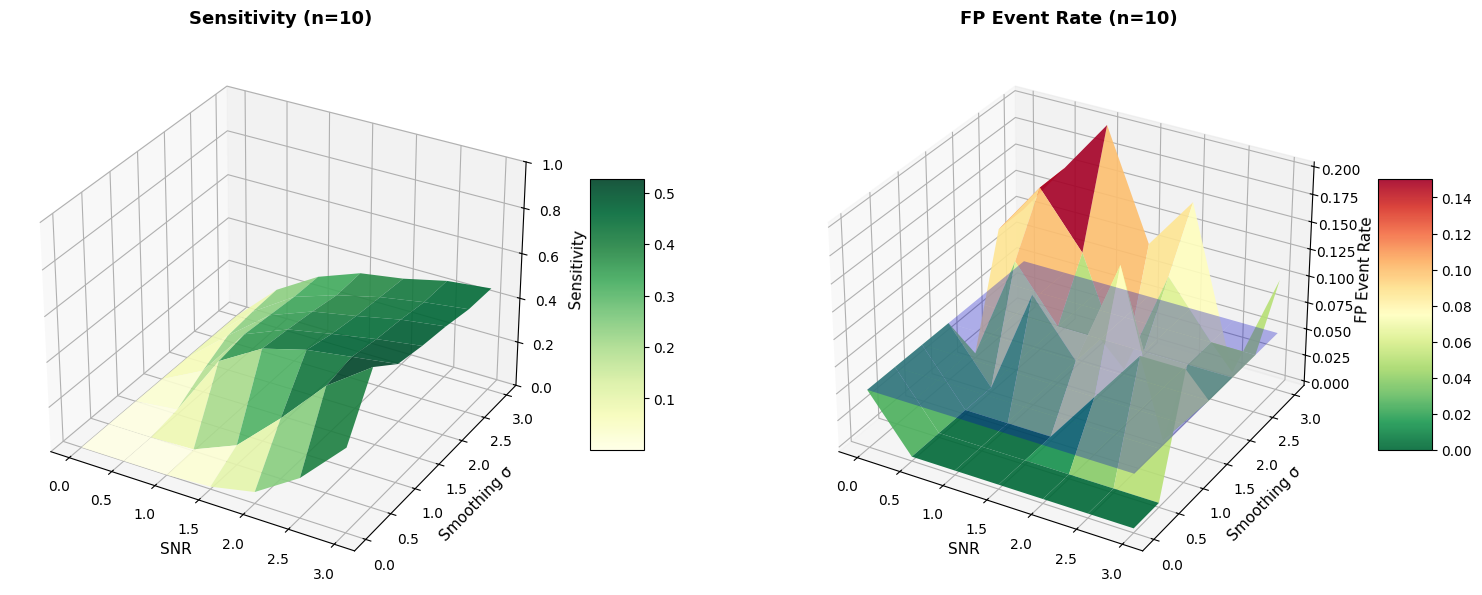

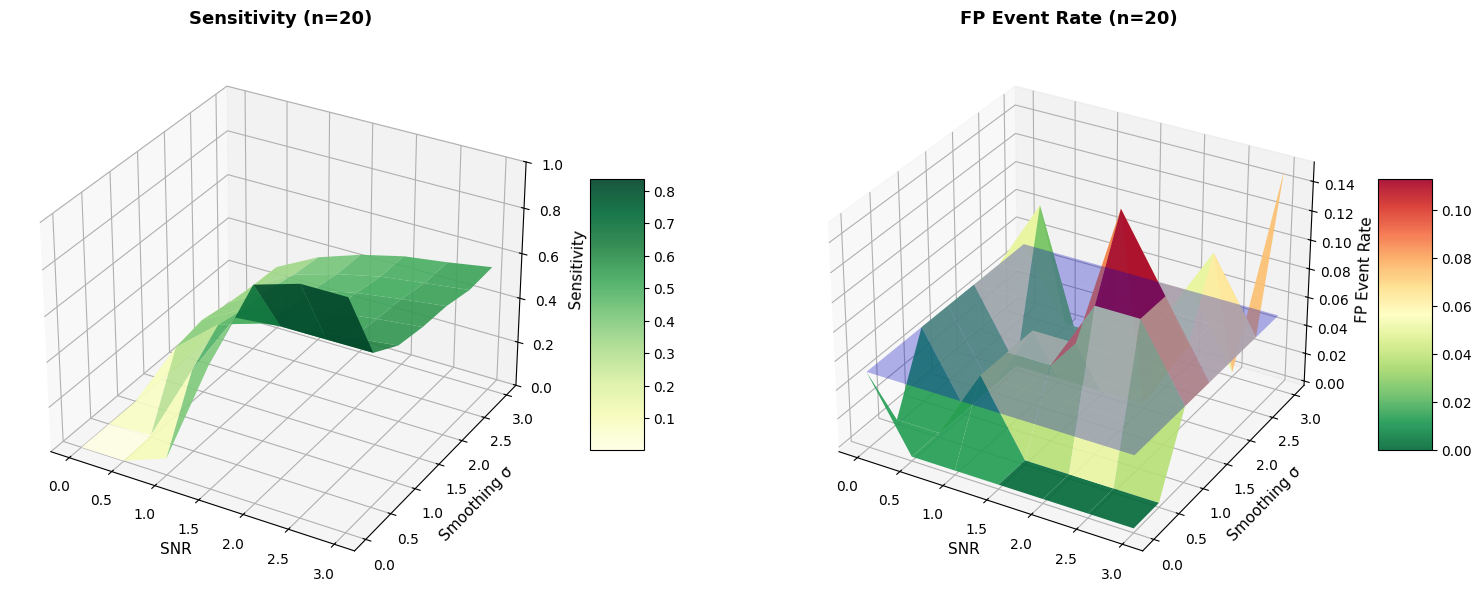

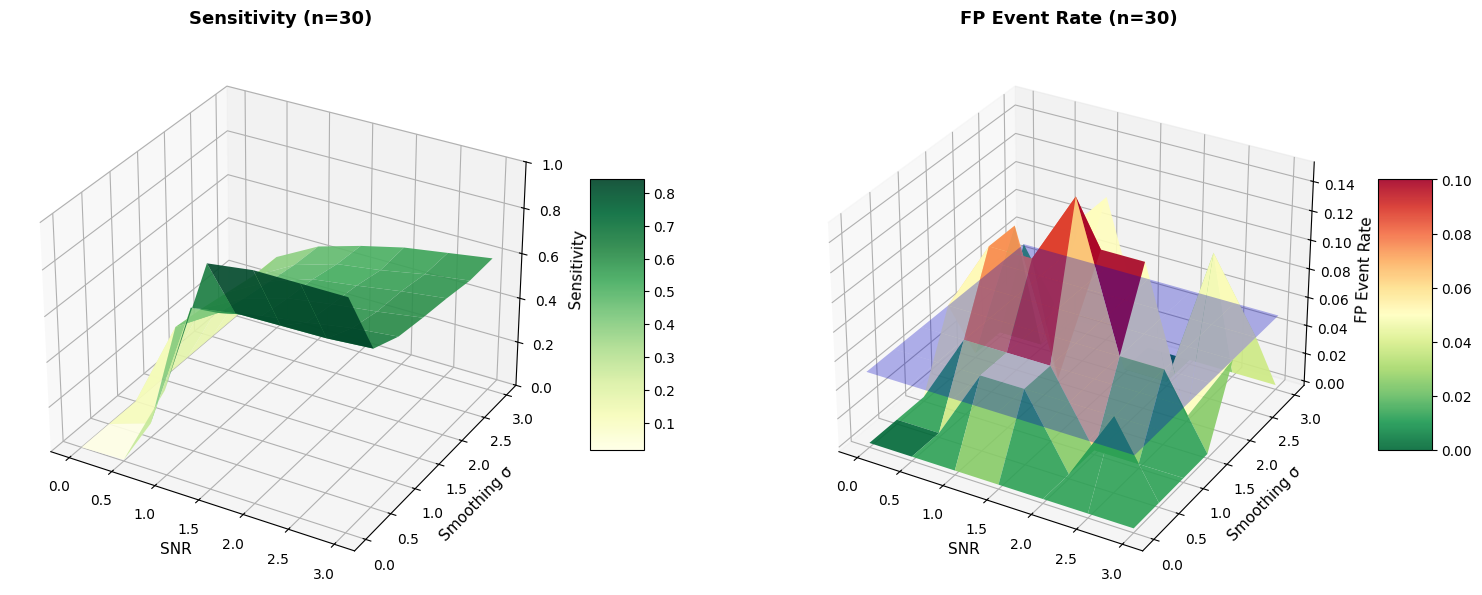

In [17]:
# Plot for each sample size (if data available)
if 'varied_n_metrics' in locals():
    for n_subj_temp, (sens_mat_temp, fwer_mat_temp) in zip(n_values, varied_n_metrics):
        plot_performance_landscape(
            snr_levels=test_snrs,
            sigma_levels=test_sigmas,
            sens_matrix=sens_mat_temp,
            fp_event_matrix=fwer_mat_temp,
            alpha=alpha,
            title_left=f"Sensitivity (n={n_subj_temp})",
            title_right=f"FP Event Rate (n={n_subj_temp})"
        )
        plt.show()
else:
    print("Run the previous cell first.")

# **PART 5:** Results and Comparison

## **5.1** Create Metrics DataFrame

Organise results into a pandas DataFrame for analysis and comparison.

In [18]:
# Create DataFrame from varied-n results (if available)
if 'varied_n_metrics' in locals():
    rows = []
    
    for n_subj_temp, (sens_mat, fwer_mat) in zip(n_values, varied_n_metrics):
        # Loop: first sigma, then snr (same order as permutation test)
        for i, sigma in enumerate(test_sigmas):
            for j, snr in enumerate(test_snrs):
                rows.append({
                    "fwer": fwer_mat[i, j],
                    "sensitivity": sens_mat[i, j],
                    "sm_sigma": sigma,
                    "snr": snr,
                    "n": n_subj_temp
                })
    
    metrics_df = pd.DataFrame(rows)
    metrics_df["method"] = "voxelwise_rft"
    
    print(f"DataFrame created:")
    print(f"  Shape: {metrics_df.shape}")
    print(f"  Columns: {list(metrics_df.columns)}")
    
    # Display sample
    print(f"\nSample rows:")
    display(metrics_df.head(10))
    
    # Save to CSV
    output_file = "voxel_wise_rft_metrics_notebook.csv"
    metrics_df.to_csv(output_file, index=False)
    print(f"\nSaved to: {output_file}")
else:
    print("No varied-n data available.")

DataFrame created:
  Shape: (147, 6)
  Columns: ['fwer', 'sensitivity', 'sm_sigma', 'snr', 'n', 'method']

Sample rows:


,fwer,sensitivity,sm_sigma,snr,n,method
0,0.05,0.000000,0.0,0.0,10,voxelwise_rft
1,0.00,0.000000,0.0,0.5,10,voxelwise_rft
2,0.00,0.000442,0.0,1.0,10,voxelwise_rft
3,0.00,0.011062,0.0,1.5,10,voxelwise_rft
4,0.00,0.051327,0.0,2.0,10,voxelwise_rft
5,0.00,0.177434,0.0,2.5,10,voxelwise_rft
6,0.00,0.372566,0.0,3.0,10,voxelwise_rft
7,0.05,0.000000,0.5,0.0,10,voxelwise_rft
8,0.00,0.000296,0.5,0.5,10,voxelwise_rft
9,0.00,0.007101,0.5,1.0,10,voxelwise_rft



Saved to: voxel_wise_rft_metrics_notebook.csv


## **5.2** Summary Statistics

In [19]:
if 'metrics_df' in locals():
    print("SUMMARY STATISTICS BY SAMPLE SIZE")
    
    for n in sorted(metrics_df['n'].unique()):
        df_n = metrics_df[metrics_df['n'] == n]
        
        # Null FWER
        null_fwer = df_n[(df_n['snr'] == 0) & (df_n['sm_sigma'] == 0)]['fwer'].values
        
        print(f"\nn = {n}:")
        print(f"  Rows: {len(df_n)}")
        print(f"  FWER at null: {null_fwer[0]:.3f} (target: 0.05)" if len(null_fwer) > 0 else "  No null data")
        print(f"  Mean FWER: {df_n['fwer'].mean():.3f}")
        print(f"  Mean sensitivity: {df_n['sensitivity'].mean():.3f}")
        print(f"  Max sensitivity: {df_n['sensitivity'].max():.3f}")
else:
    print("No DataFrame.")

SUMMARY STATISTICS BY SAMPLE SIZE

n = 10:
  Rows: 49
  FWER at null: 0.050 (target: 0.05)
  Mean FWER: 0.051
  Mean sensitivity: 0.266
  Max sensitivity: 0.612

n = 20:
  Rows: 49
  FWER at null: 0.050 (target: 0.05)
  Mean FWER: 0.038
  Mean sensitivity: 0.426
  Max sensitivity: 1.000

n = 30:
  Rows: 49
  FWER at null: 0.000 (target: 0.05)
  Mean FWER: 0.032
  Mean sensitivity: 0.476
  Max sensitivity: 1.000


## Resources

### Code Files:
- `rft_voxelwise.py` - Main RFT implementation
- `rft_plotters.py` - Plotting functions
- `generate_rft_metrics.py` - Generate full metrics dataset
- `fwer_test.py` - Test FWER control

### Key Papers:
- Adler et al. (2017) "Estimating Thresholding Levels for Random Fields via Euler Characteristics"
- Worsley et al. (1996) "A unified statistical approach for determining significant signals in images of cerebral activation"